# Artificial Neural Networks
## Week 3, Day 1 



## Contents

1. [1. Why Neural Networks Matter](#sec1)
2. [2. History at a Glance](#sec2)
3. [3. From Biological Neuron to Code](#sec3)
4. [4. The Perceptron](#sec4)
5. [5. Network Anatomy](#sec5)
6. [6. The Core Math](#sec6)
7. [7. Activation Functions](#sec7)
8. [8. Forward Pass — Worked Example](#sec8)
9. [9. Hyperparameters](#sec9)
10. [10. Strengths and Limitations](#sec10)
11. [11. Real-World Applications](#sec11)
12. [12. Applied Project Summary](#sec12)
13. [13. Conclusion](#sec13)
14. [14. References](#sec14)

---

<a id="sec1"></a>
# 1. Why Neural Networks Matter

Classical programs need a human to spell out every rule in advance. **Deep Learning** turns this around: a network is shown many labeled examples and adjusts its own internal numbers until it produces the right answers on its own.

An **Artificial Neural Network (ANN)** is the structure that makes this possible — many small computing units ("neurons") arranged in layers, each doing a simple transformation, that together can approximate mappings far too complex to hand-code.

Why this is worth learning first:

- **No manual feature engineering.** The network discovers which combinations of inputs matter instead of a human choosing them.
- **One architecture, many domains.** The same layered design underlies systems for images, language, audio, and tabular data — only the input/output shape changes.
- **Everything else builds on it.** CNNs, RNNs, and Transformers are all specialised variations of the plain, fully-connected ANN covered here.

<p align="center">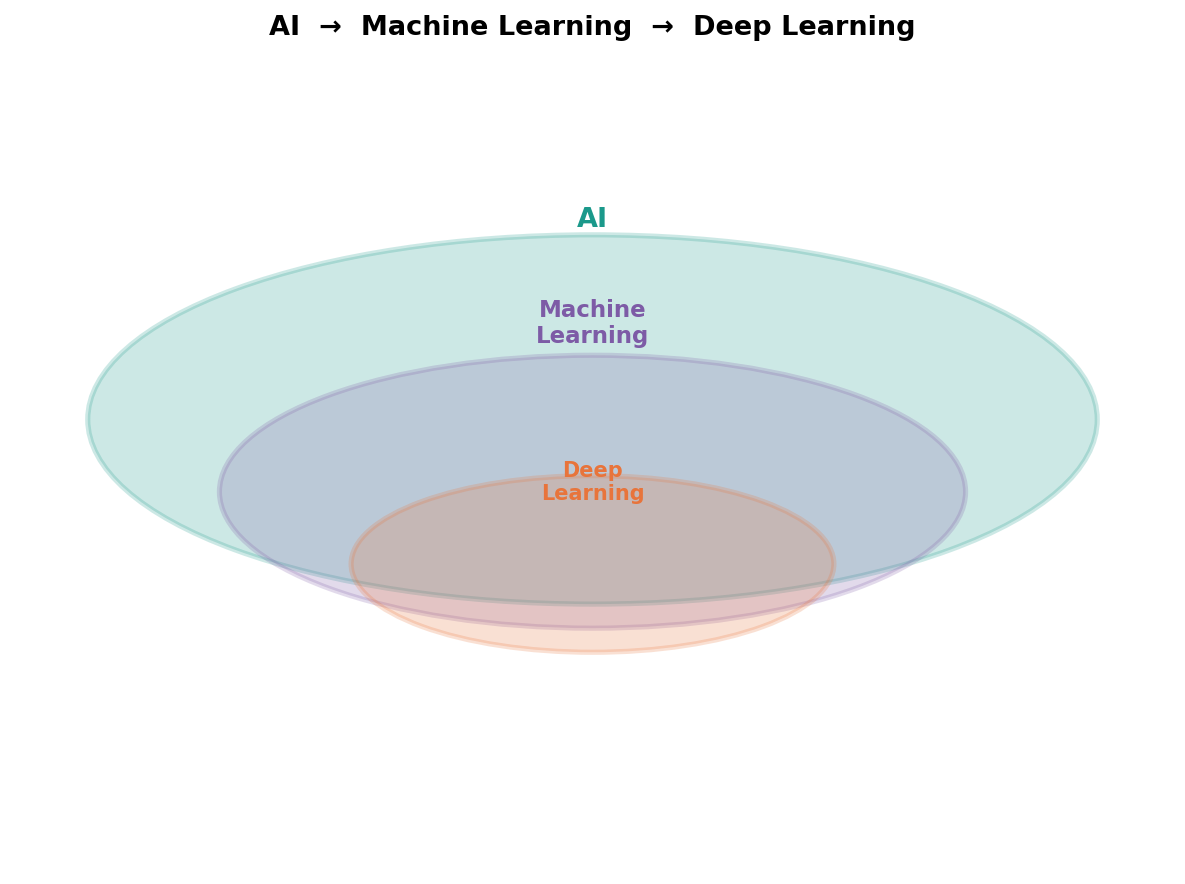</p>

<a id="sec2"></a>
# 2. History at a Glance

| Year | Milestone |
|---|---|
| 1943 | McCulloch & Pitts publish the first mathematical model of a neuron. |
| 1958 | Rosenblatt's Perceptron becomes the first neural model that can learn from data. |
| 1969 | Minsky & Papert prove a single perceptron cannot solve XOR — research funding stalls ("AI winter"). |
| 1986 | Backpropagation is popularised, making multi-layer networks trainable again. |
| 1990s–2000s | Progress is limited by available compute and data. |
| 2012 | AlexNet wins ImageNet by a wide margin, kicking off the modern deep learning era. |
| 2017–present | Attention and Transformer architectures extend deep learning into language and multimodal tasks. |

<a id="sec3"></a>
# 3. From Biological Neuron to Code

<p align="center">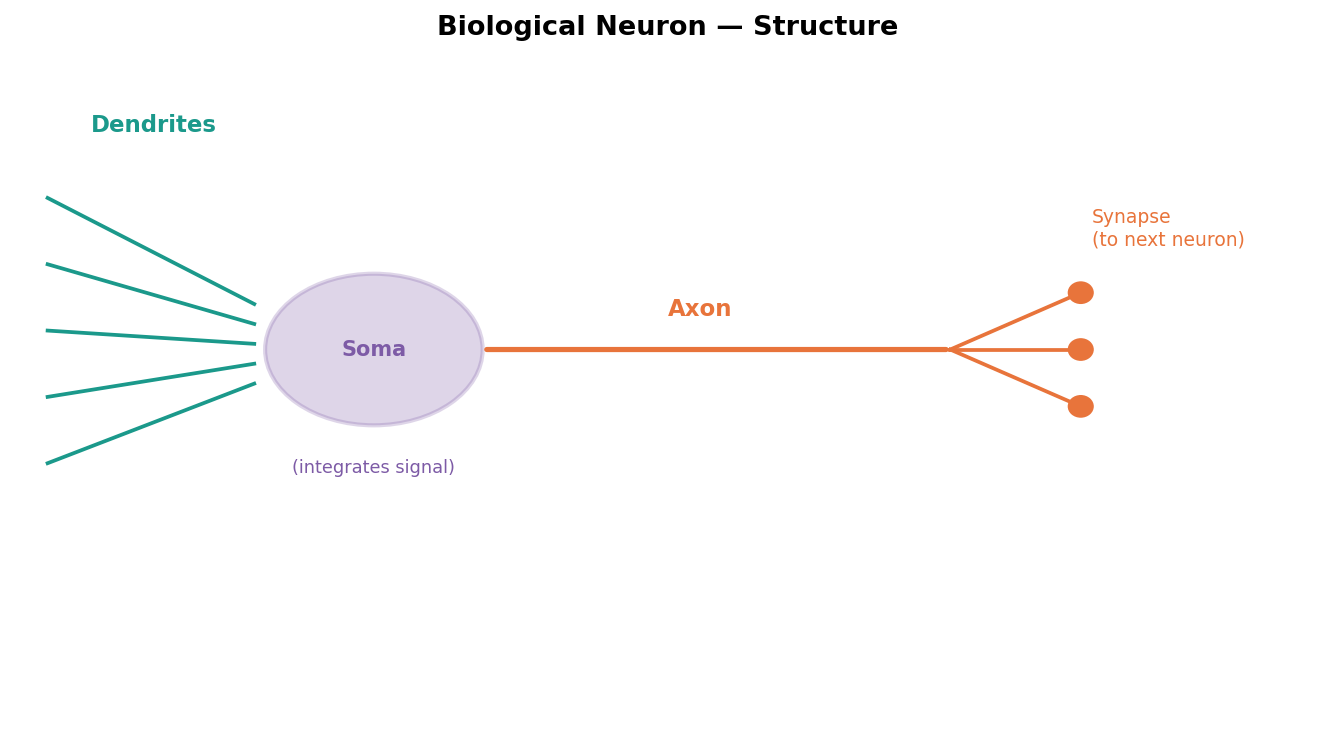</p>

| Stage | Biology | ANN Equivalent |
|---|---|---|
| Signal collection | Dendrites receive electrochemical input from neighbouring cells. | Inputs `x1, x2, ..., xn` are each multiplied by a weight. |
| Integration | The soma sums the incoming charge. | A weighted sum `z = Σ(wᵢxᵢ) + b` is computed. |
| Firing decision | The cell fires only once a voltage threshold is crossed. | An activation function `f(z)` decides how strongly the neuron "fires". |
| Transmission | The axon and synapse pass the signal to the next neuron. | The activated value `a = f(z)` becomes an input to the next layer. |

**Key differences worth remembering:**

| Aspect | Biological Neuron | Artificial Neuron |
|---|---|---|
| Signal type | Electrochemical pulses | Real-valued numbers |
| Learning rule | Synaptic plasticity (Hebbian) | Gradient-based weight updates |
| Scale | ~10¹¹ neurons, massively parallel | Thousands to billions of parameters, parallel on hardware |
| Wiring | Irregular, grown organically | Regular, layered, mathematically defined |
| Firing behaviour | Mostly all-or-nothing | Smooth/continuous in most modern activations |

<p align="center">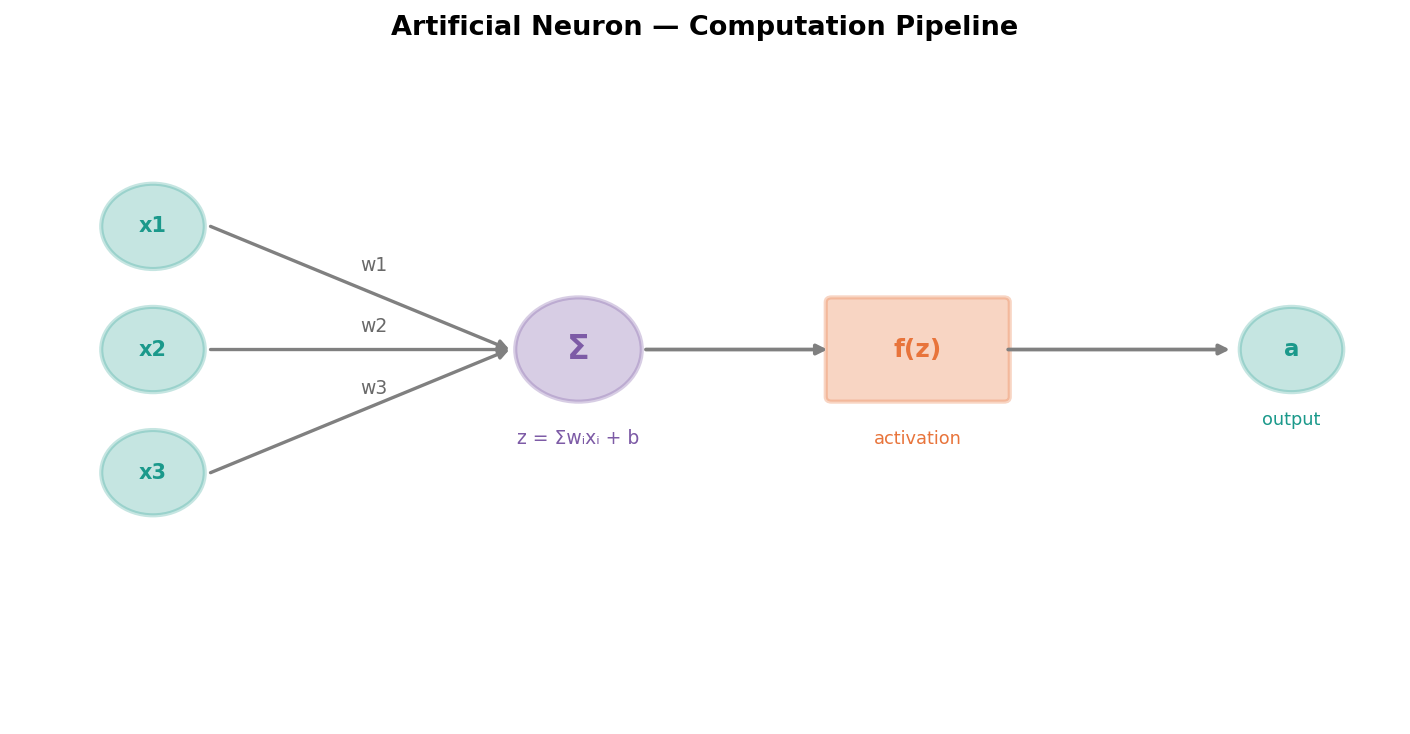</p>

A single artificial neuron packages this whole pipeline into one small routine: it stores its own weights and bias, and a `forward` step does the "sum, then activate" computation in a couple of lines.

<a id="sec4"></a>
# 4. The Perceptron

The **Perceptron**, introduced by Frank Rosenblatt in 1958, is the simplest trainable neural unit — a single neuron with a hard step activation.

**Decision rule:**

```
z = Σ(wᵢxᵢ) + b
y = 1   if z ≥ 0
y = 0   otherwise
```

**Weight update rule (Perceptron Learning Rule):**

```
wᵢ ← wᵢ + η · (y_true − y_pred) · xᵢ
```

where `η` is the learning rate.

<p align="center">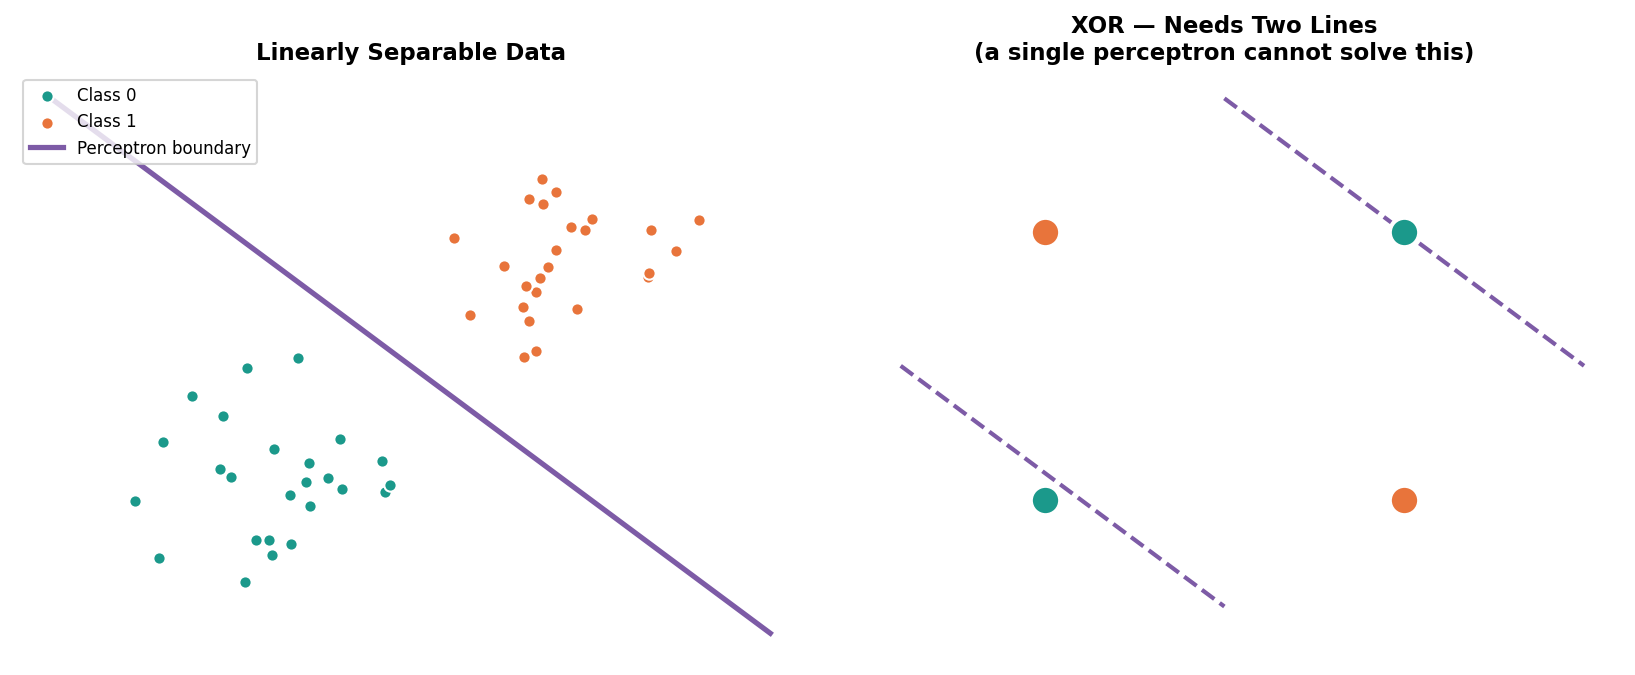</p>

This rule works well when classes are linearly separable, but in 1969 Minsky and Papert showed a single perceptron can never learn XOR — a problem that needs a curved or piecewise decision boundary (shown on the right above). Solving it required stacking multiple layers together, which is exactly what backpropagation later made practical.

**Trade-offs:**

| Strength | Weakness |
|---|---|
| Very cheap to compute | Draws only a single straight decision boundary |
| Simple to interpret, weight by weight | Hard 0/1 output only — no confidence score |
| Guaranteed to converge on linearly separable data | Cannot represent XOR-style patterns |

<a id="sec5"></a>
# 5. Network Anatomy

Stacking many perceptron-like units into layers gives a full ANN:

- **Input layer** — one slot per feature; performs no computation of its own.
- **Hidden layer(s)** — where representation learning actually happens; every neuron here combines the *entire* output of the previous layer.
- **Output layer** — shaped to the task: one neuron for binary classification, `N` neurons with softmax for `N`-class classification, or a single linear neuron for regression.
- **Weights & biases** — the learnable parameters that connect every neuron in one layer to every neuron in the next (a fully-connected / dense design).

<p align="center">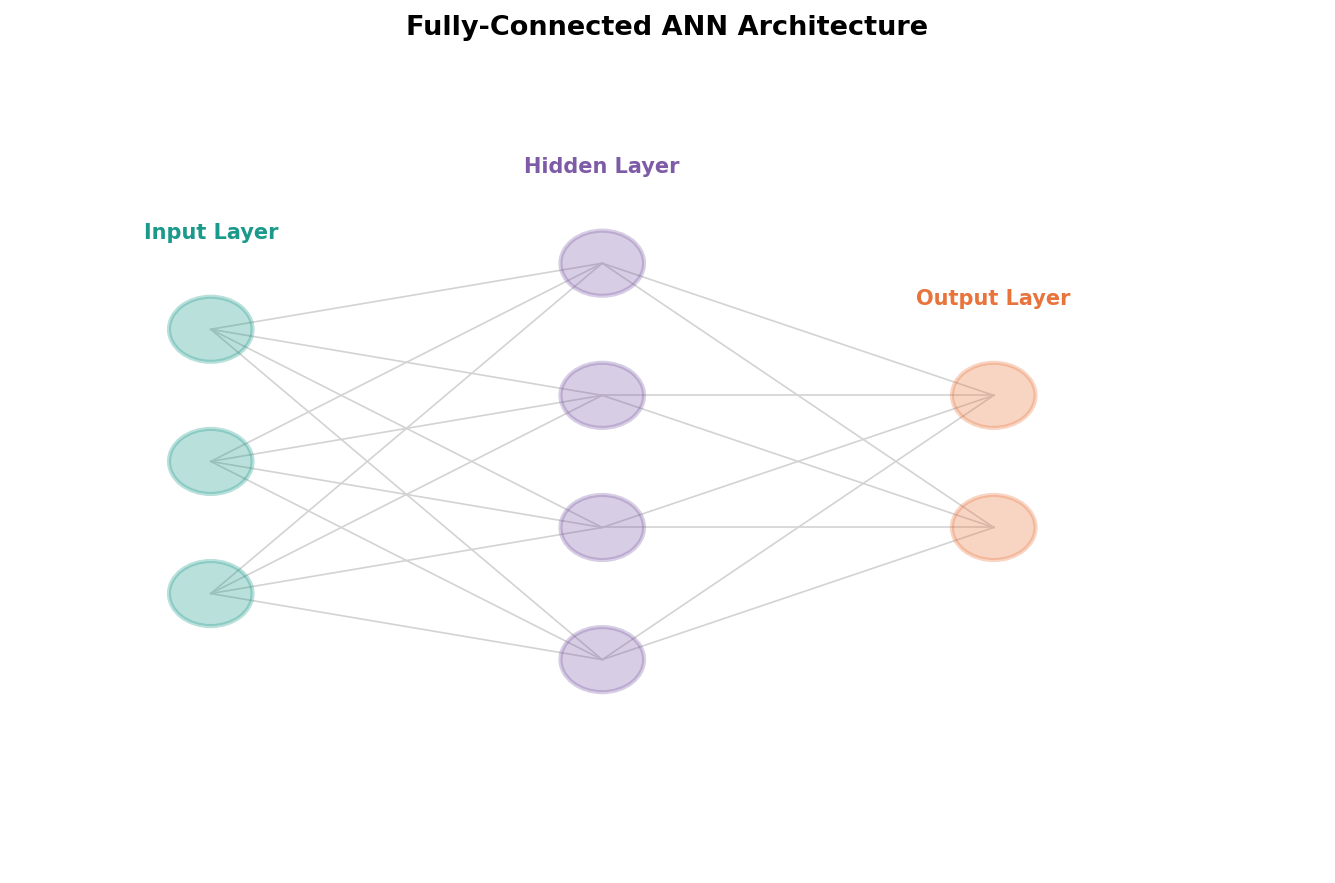</p>

A network is essentially a small list of layers chained together — for example, a `[2, 3, 1]` layer-size list describes a 2-input, one-hidden-layer (3 neurons), single-output network, which is the exact topology used in the worked example below.

<a id="sec6"></a>
# 6. The Core Math

Every layer performs the same two operations in sequence.

**Step 1 — Linear combination:**

```
Z = W · A_prev + b
```

**Step 2 — Non-linear activation:**

```
A = f(Z)
```

`W` is the weight matrix (one row per neuron, one column per input), `b` is the bias vector, and `f` is the activation function applied element-wise. Every layer in the network runs exactly these two lines — the only differences between layers are the shapes of `W`/`b` and the choice of `f`.

<a id="sec7"></a>
# 7. Activation Functions

Without a non-linear activation, stacking any number of layers would still collapse into one big linear function — depth would add no extra representational power. Activation functions are what give a deep network its ability to model curved, complex decision boundaries.

| Function | Formula | Range | Best used for |
|---|---|---|---|
| Binary Step | `1 if z≥0 else 0` | {0, 1} | Historical perceptrons only — not differentiable |
| Sigmoid | `1 / (1 + e^-z)` | (0, 1) | Binary output layer, interpreted as a probability |
| Tanh | `(e^z − e^-z) / (e^z + e^-z)` | (−1, 1) | Hidden layers needing zero-centred output |
| ReLU | `max(0, z)` | [0, ∞) | Default choice for most hidden layers |
| Leaky ReLU | `z if z>0 else αz` | (−∞, ∞) | Fixes "dying ReLU" neurons that get stuck at 0 |
| ELU | `z if z>0 else α(e^z − 1)` | (−α, ∞) | Smoother negative-side gradients, faster convergence |
| Softmax | `e^zᵢ / Σⱼe^zⱼ` | (0, 1), sums to 1 | Multi-class output layer only |

<p align="center">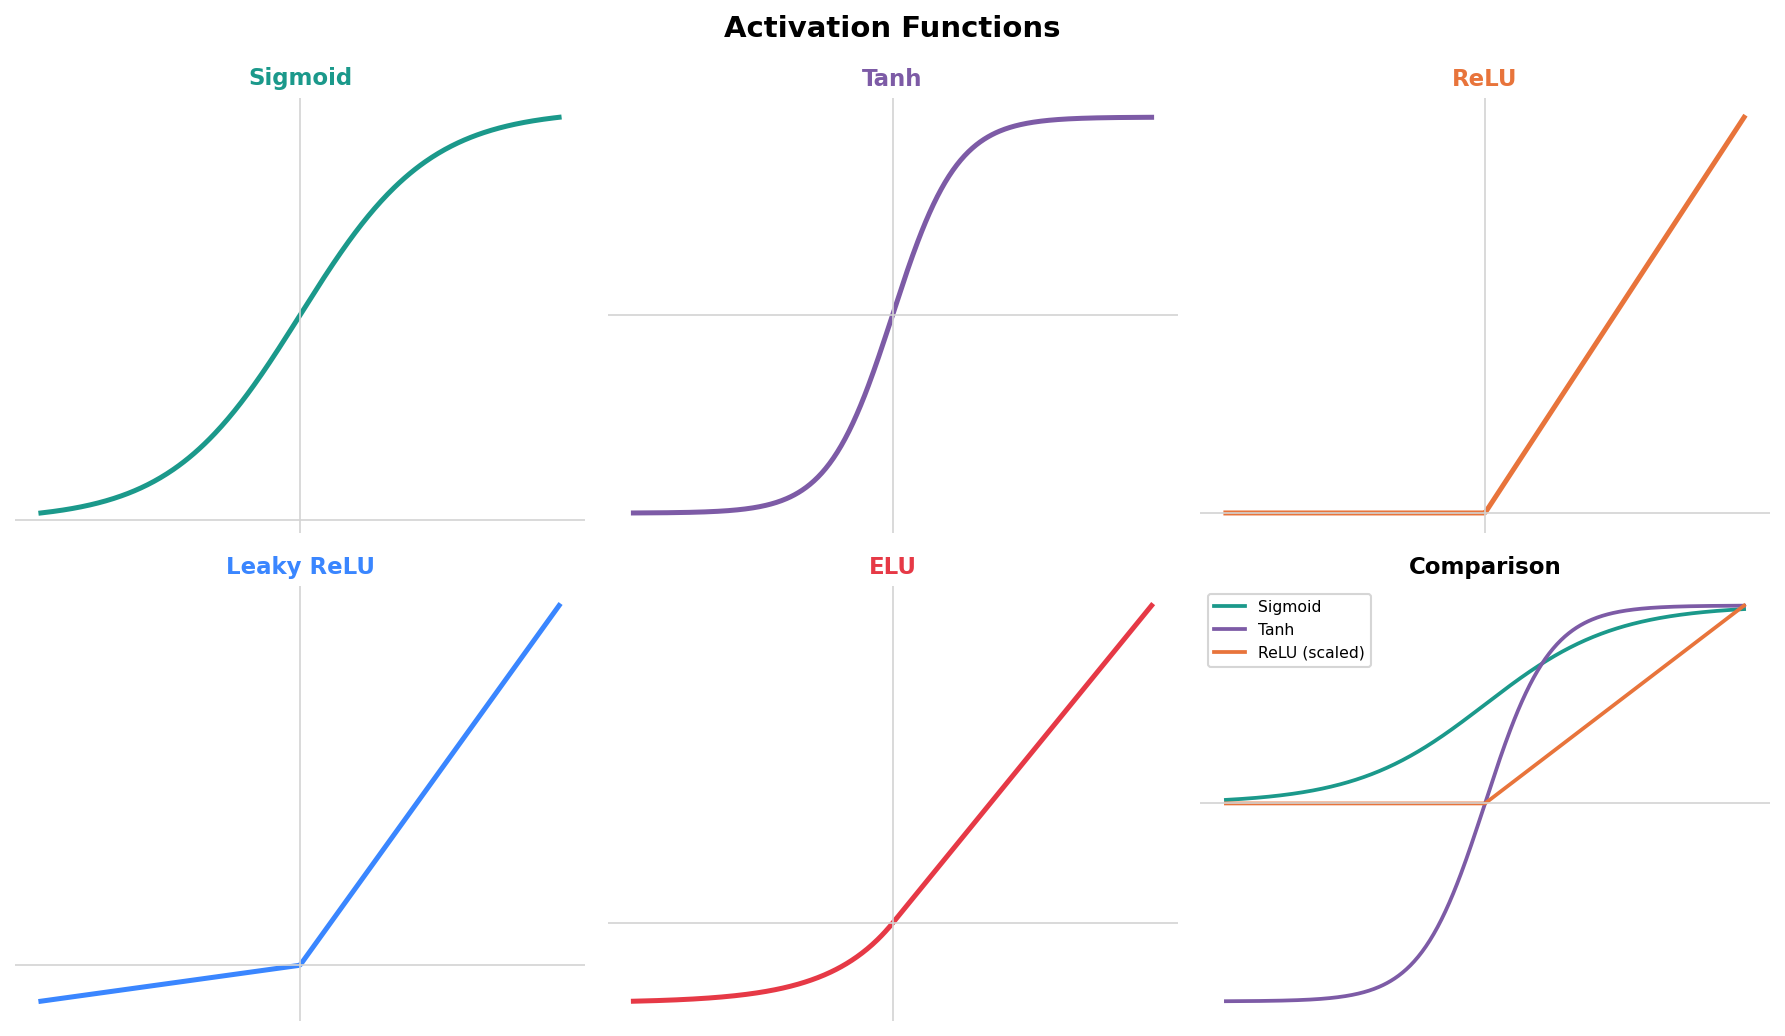</p>

Softmax is a special case worth calling out separately: instead of activating one value at a time, it looks at an entire vector of raw scores ("logits") and converts them into a probability distribution over classes that sums to 1.

<p align="center">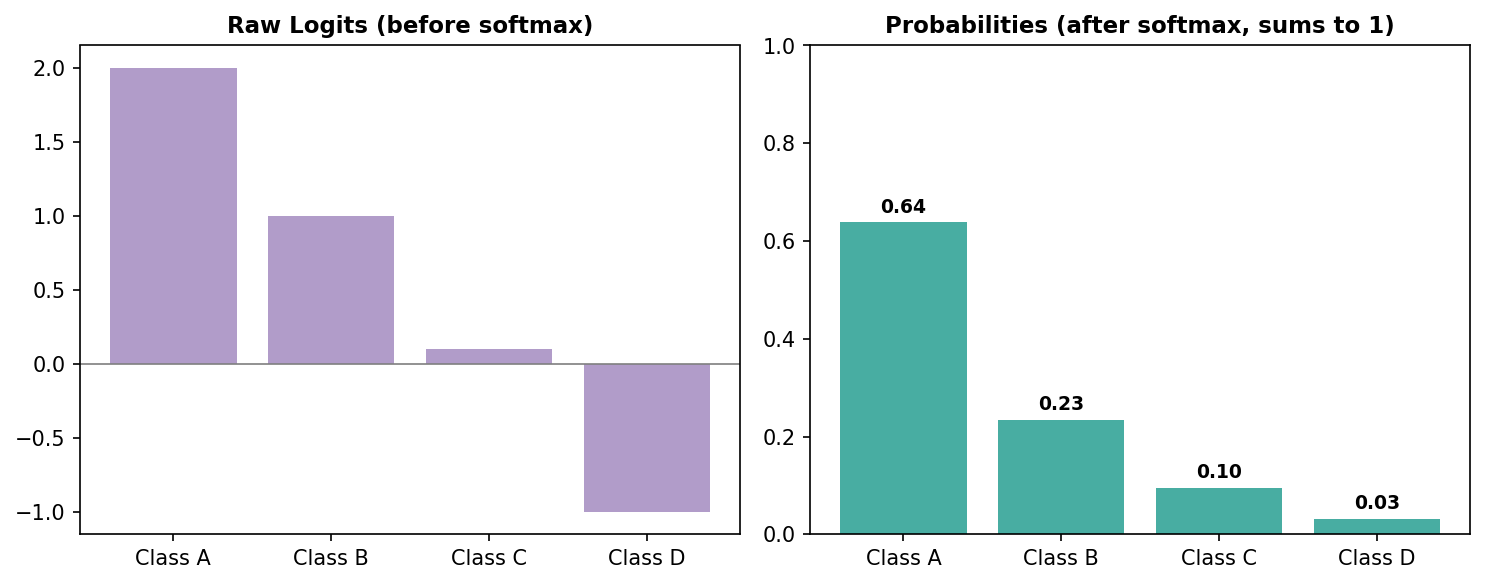</p>

<a id="sec8"></a>
# 8. Forward Pass — Worked Example

**Forward propagation** is simply applying the two equations from Section 6 repeatedly, layer after layer, until the final layer produces a prediction.

For a `2 → 3 → 1` network with input `X = [0.6, 0.9]`, hidden weights `W1` and bias `b1`, and output weights `W2` and bias `b2`:

```
Hidden layer (2 → 3, tanh):
    Z1 = W1·X + b1
    A1 = tanh(Z1)

Output layer (3 → 1, sigmoid):
    Z2 = W2·A1 + b2
    A2 = sigmoid(Z2)   ← final prediction, a probability between 0 and 1
```

<p align="center">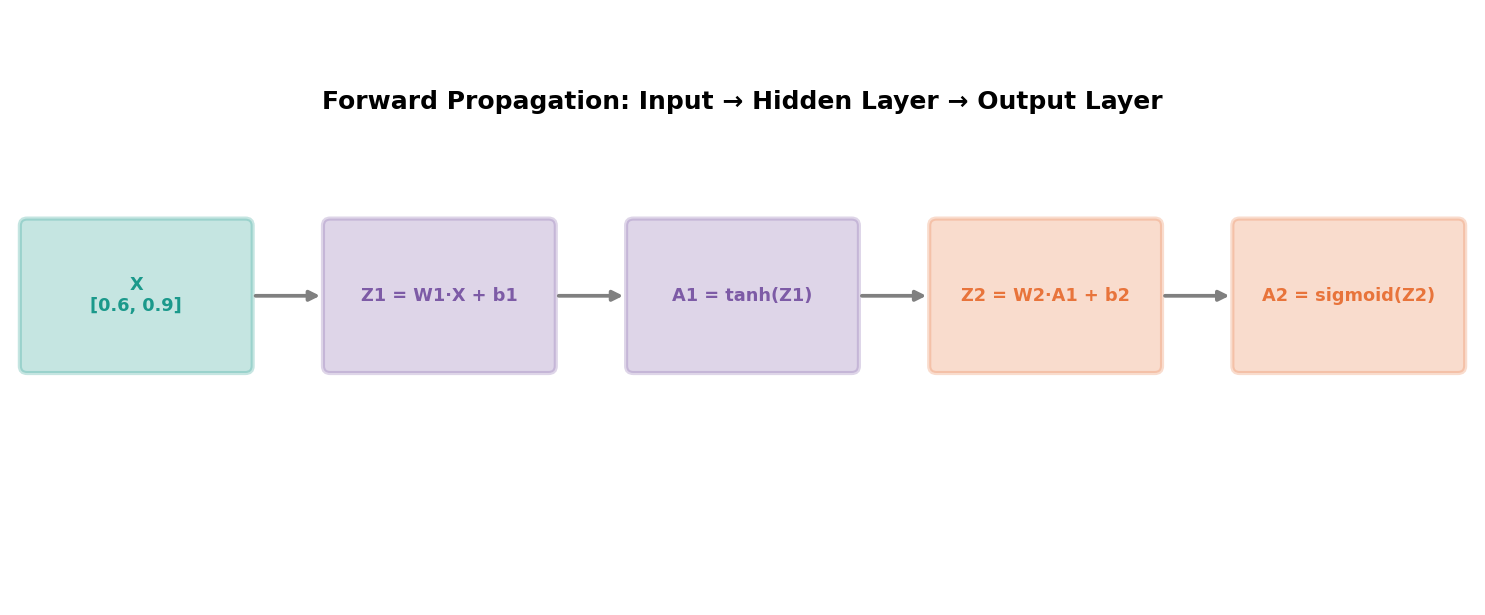</p>

This same computation, run with real numeric weights, is executed step by step in the cells below and then cross-checked against an equivalent TensorFlow/Keras model — both approaches agree to within floating-point precision, confirming the manual implementation is mathematically correct.

In [ ]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Input
X = np.array([0.6, 0.9])

# Hidden layer weights (3 neurons, 2 inputs each) and bias
np.random.seed(42)
W1 = np.round(np.random.uniform(-1, 1, size=(3, 2)), 2)
b1 = np.round(np.random.uniform(-1, 1, size=(3,)), 2)

# Output layer weights (1 neuron, 3 inputs) and bias
W2 = np.round(np.random.uniform(-1, 1, size=(1, 3)), 2)
b2 = np.round(np.random.uniform(-1, 1, size=(1,)), 2)

# Forward pass
Z1 = W1 @ X + b1
A1 = np.tanh(Z1)

Z2 = W2 @ A1 + b2
A2 = sigmoid(Z2)

print("Z1 (hidden weighted sum):", Z1)
print("A1 (hidden activation)  :", A1)
print("Z2 (output weighted sum):", Z2)
print("A2 (final prediction)   :", A2)

<a id="sec9"></a>
# 9. Hyperparameters

Unlike weights and biases, hyperparameters are **not learned** — they're chosen by the practitioner before training starts:

- **Learning rate (η)** — the size of each weight update step. Too high causes divergence; too low makes training painfully slow.
- **Batch size** — how many samples are averaged before each weight update. Smaller batches update more often but noisily; larger batches are smoother but slower per step.
- **Epochs** — how many full passes through the training data are performed.
- **Depth (hidden layers)** — controls how many levels of abstraction the network can build.
- **Width (neurons per layer)** — controls how much capacity each layer has.
- **Dropout rate** — randomly disables a fraction of neurons during training to reduce overfitting.

<a id="sec10"></a>
# 10. Strengths and Limitations

**Where ANNs shine:**
- Learn directly from raw data — no manual feature engineering required.
- Can, in principle, approximate any continuous function given enough capacity (Universal Approximation Theorem).
- Scale predictably with more data and more compute, and parallelise well on GPUs/TPUs.

**Where they struggle:**
- Need large amounts of labeled data to generalise well.
- Expensive to train, especially as depth increases.
- Behave as a "black box" — decisions are hard to explain.
- Can overfit (memorise noise) without regularisation such as dropout or weight decay.
- Deep stacks are prone to vanishing or exploding gradients without careful design.

<a id="sec11"></a>
# 11. Real-World Applications

- **Medical diagnostics** — classifying tumours or diseases from imaging or clinical data (the applied project below uses exactly this kind of dataset).
- **Computer vision** — object detection, face recognition, scene understanding.
- **Finance** — credit scoring, fraud detection, algorithmic trading.
- **Speech & language** — transcription, translation, conversational agents.
- **Recommendation systems** — personalised product and content ranking.
- **Forecasting** — demand planning, energy load prediction, stock trends.

<a id="sec12"></a>
# 12. Applied Project Summary

The concepts above were first sanity-checked with a small from-scratch network; the applied project then moves to a production-style, dropout-regularised Keras model trained on the **Breast Cancer Wisconsin** dataset (569 samples, 30 numeric features, malignant vs. benign).

**What the pipeline covers:**
- Loading and scaling the dataset, then splitting into train/validation/test sets.
- Training the Keras model with dropout for regularisation, tracking loss and accuracy on both training and validation data each epoch.
- Evaluating on the held-out test set with a confusion matrix and a full classification report (precision, recall, F1-score per class).

The model reaches strong test accuracy with training and validation curves that stay close together — a sign of limited overfitting — and the confusion matrix shows very few misclassifications in either direction. Full numeric results, plots, and the classification report are available in the companion notebook.

<a id="sec13"></a>
# 13. Conclusion

Artificial Neural Networks are the mathematical and architectural foundation underneath almost all of modern deep learning. Starting from a simple biological analogy, this assignment worked through the Perceptron, the anatomy of a multi-layer network, the math behind forward propagation, the role of activation functions, and the hyperparameters a practitioner controls — then validated all of it against a from-scratch implementation and a production Keras model trained on real medical data. This sets up the next topics directly: **backpropagation** (how the network actually learns) and **Convolutional Neural Networks** (how it learns from spatial data such as images).

<a id="sec14"></a>
# 14. References

1. McCulloch, W. S., & Pitts, W. (1943). *A logical calculus of the ideas immanent in nervous activity.* Bulletin of Mathematical Biophysics, 5(4).
2. Rosenblatt, F. (1958). *The perceptron: A probabilistic model for information storage and organization in the brain.* Psychological Review, 65(6).
3. Minsky, M., & Papert, S. (1969). *Perceptrons: An Introduction to Computational Geometry.* MIT Press.
4. Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). *Learning representations by back-propagating errors.* Nature, 323.
5. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning.* MIT Press. https://www.deeplearningbook.org/
6. Srivastava, N. et al. (2014). *Dropout: A Simple Way to Prevent Neural Networks from Overfitting.* JMLR.
7. Nielsen, M. (2015). *Neural Networks and Deep Learning.* http://neuralnetworksanddeeplearning.com/
8. TensorFlow/Keras Documentation. https://www.tensorflow.org/guide
9. Scikit-learn Documentation — Breast Cancer Wisconsin dataset. https://scikit-learn.org/stable/datasets/toy_dataset.html
10. NumPy Documentation. https://numpy.org/doc/